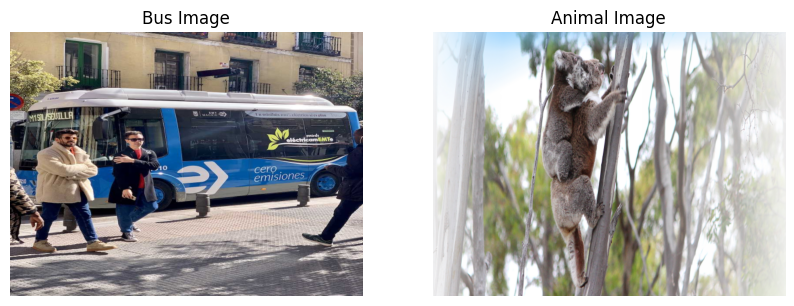

In [2]:
import cv2
import numpy as np
import time
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline


image_path = 'backend/data/bus.jpg'  
yolo_model_path = 'backend/resource/models/yolov8n-seg.pt'
animal_image_path = 'capture2.jpg'  
animal_image_path = 'backend/data/koala.jpg'  


# Load the test image
bus_image = cv2.imread(image_path)
if bus_image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")
animal_image = cv2.imread(animal_image_path) if animal_image_path else bus_image  # 回退到 bus.jpg

# Resize images to 640x480 for edge device simulation
bus_image_resized = cv2.resize(bus_image, (640, 480), interpolation=cv2.INTER_AREA)
animal_image_resized = cv2.resize(animal_image, (640, 480), interpolation=cv2.INTER_AREA)

# Load YOLOv8n-seg model
yolo_model = YOLO(yolo_model_path)

# Show the original images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(bus_image_resized, cv2.COLOR_BGR2RGB))
plt.title('Bus Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(animal_image_resized, cv2.COLOR_BGR2RGB))
plt.title('Animal Image')
plt.axis('off')
plt.show()

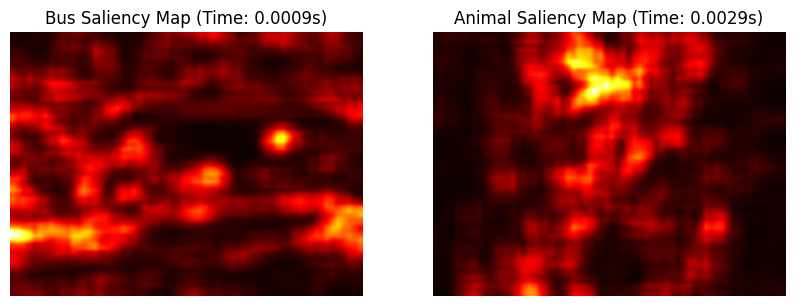

Bus Saliency Time: 0.0009 seconds
Animal Saliency Time: 0.0029 seconds


In [4]:
# Initialize the saliency detector
saliency = cv2.saliency.StaticSaliencySpectralResidual_create()

# Calculate saliency maps for both images
start_time = time.time()
_, bus_saliency_map = saliency.computeSaliency(bus_image_resized)
bus_saliency_time = time.time() - start_time
_, animal_saliency_map = saliency.computeSaliency(animal_image_resized)
animal_saliency_time = time.time() - start_time - bus_saliency_time

# Normalize saliency maps to [0, 255]
bus_saliency_map = (bus_saliency_map * 255).astype(np.uint8)
animal_saliency_map = (animal_saliency_map * 255).astype(np.uint8)

# Visualize the saliency maps
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(bus_saliency_map, cmap='hot')
plt.title(f'Bus Saliency Map (Time: {bus_saliency_time:.4f}s)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(animal_saliency_map, cmap='hot')
plt.title(f'Animal Saliency Map (Time: {animal_saliency_time:.4f}s)')
plt.axis('off')
plt.show()

print(f"Bus Saliency Time: {bus_saliency_time:.4f} seconds")
print(f"Animal Saliency Time: {animal_saliency_time:.4f} seconds")

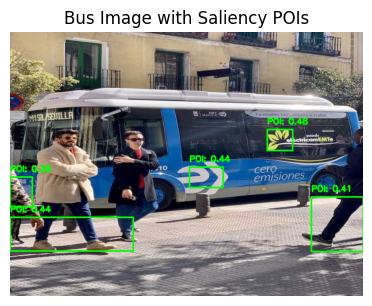

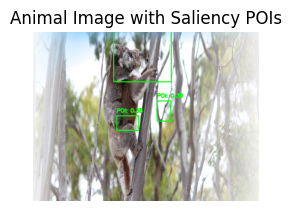

Bus Saliency POIs: [{'bbox': [0, 337, 223, 398], 'saliency_score': 0.4398680798497448, 'type': 'unknown'}, {'bbox': [546, 300, 640, 399], 'saliency_score': 0.4095279031449244, 'type': 'unknown'}, {'bbox': [0, 264, 40, 318], 'saliency_score': 0.3905446623093682, 'type': 'unknown'}, {'bbox': [325, 246, 386, 283], 'saliency_score': 0.4411756018313395, 'type': 'unknown'}, {'bbox': [466, 178, 512, 216], 'saliency_score': 0.48143760936869023, 'type': 'unknown'}]
Animal Saliency POIs: [{'bbox': [237, 239, 299, 280], 'saliency_score': 0.37768007281590843, 'type': 'unknown'}, {'bbox': [351, 197, 390, 254], 'saliency_score': 0.3893643107265398, 'type': 'unknown'}, {'bbox': [228, 0, 391, 143], 'saliency_score': 0.4182031850021745, 'type': 'unknown'}]


In [5]:
# Threshold and extract points of interest (POIs) from saliency maps
def extract_saliency_pois(saliency_map, threshold=100, min_area=1000):
    _, binary = cv2.threshold(saliency_map, threshold, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pois = []
    for contour in contours:
        if cv2.contourArea(contour) > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            score = np.mean(saliency_map[y:y+h, x:x+w]) / 255.0
            pois.append({"bbox": [x, y, x+w, y+h], "saliency_score": score, "type": "unknown"})
    return pois

# Extract POIs from saliency maps
bus_pois = extract_saliency_pois(bus_saliency_map)
animal_pois = extract_saliency_pois(animal_saliency_map)

# Visualize POIs on the images
def visualize_pois(image, pois, title):
    img_copy = image.copy()
    for poi in pois:
        x1, y1, x2, y2 = poi["bbox"]
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, f"POI: {poi['saliency_score']:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
visualize_pois(bus_image_resized, bus_pois, 'Bus Image with Saliency POIs')
plt.subplot(1, 2, 2)
visualize_pois(animal_image_resized, animal_pois, 'Animal Image with Saliency POIs')
plt.show()

print("Bus Saliency POIs:", bus_pois)
print("Animal Saliency POIs:", animal_pois)


0: 480x640 4 persons, 1 bus, 133.2ms
Speed: 4.0ms preprocess, 133.2ms inference, 6.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bear, 69.9ms
Speed: 1.3ms preprocess, 69.9ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)


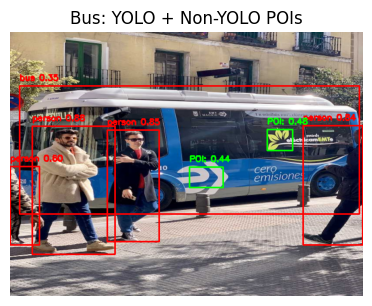

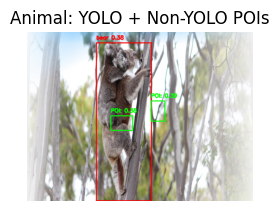

Bus YOLO Detections: [{'class': 'person', 'bbox': [40, 172, 190, 404], 'confidence': 0.8793217539787292}, {'class': 'person', 'bbox': [176, 179, 270, 381], 'confidence': 0.8509981632232666}, {'class': 'person', 'bbox': [531, 171, 639, 387], 'confidence': 0.8401371240615845}, {'class': 'person', 'bbox': [0, 245, 53, 387], 'confidence': 0.5993515253067017}, {'class': 'bus', 'bbox': [17, 99, 633, 331], 'confidence': 0.35091912746429443}]
Bus Non-YOLO POIs: [{'bbox': [325, 246, 386, 283], 'saliency_score': 0.4411756018313395, 'type': 'unknown'}, {'bbox': [466, 178, 512, 216], 'saliency_score': 0.48143760936869023, 'type': 'unknown'}]
Animal YOLO Detections: [{'class': 'bear', 'bbox': [196, 33, 352, 479], 'confidence': 0.37743937969207764}]
Animal Non-YOLO POIs: [{'bbox': [237, 239, 299, 280], 'saliency_score': 0.37768007281590843, 'type': 'unknown'}, {'bbox': [351, 197, 390, 254], 'saliency_score': 0.3893643107265398, 'type': 'unknown'}]


In [7]:
# Process the images with YOLOv8n-seg model
def run_yolo_detection(image, model):
    results = model(image)
    detections = []
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf)
            cls = int(box.cls)
            class_name = model.names[cls]
            detections.append({"class": class_name, "bbox": [x1, y1, x2, y2], "confidence": conf})
    return detections

# Detect the objects in the images
bus_detections = run_yolo_detection(bus_image_resized, yolo_model)
animal_detections = run_yolo_detection(animal_image_resized, yolo_model)

# Calculate the IoU
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x3, y3, x4, y4 = box2
    x_left = max(x1, x3)
    y_top = max(y1, y3)
    x_right = min(x2, x4)
    y_bottom = min(y2, y4)
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x4 - x3) * (y4 - y3)
    return intersection / (area1 + area2 - intersection)

# Filter non-YOLO POIs
def filter_non_yolo_pois(pois, detections, iou_threshold=0.1):
    non_yolo_pois = []
    for poi in pois:
        is_unique = True
        for det in detections:
            if calculate_iou(poi["bbox"], det["bbox"]) > iou_threshold:
                is_unique = False
                break
        if is_unique:
            non_yolo_pois.append(poi)
    return non_yolo_pois

# Extract non-YOLO POIs
bus_non_yolo_pois = filter_non_yolo_pois(bus_pois, bus_detections)
animal_non_yolo_pois = filter_non_yolo_pois(animal_pois, animal_detections)

# Visualize detections and POIs
def visualize_detections_and_pois(image, detections, pois, title):
    img_copy = image.copy()
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(img_copy, f"{det['class']} {det['confidence']:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    for poi in pois:
        x1, y1, x2, y2 = poi["bbox"]
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, f"POI: {poi['saliency_score']:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
visualize_detections_and_pois(bus_image_resized, bus_detections, bus_non_yolo_pois, 'Bus: YOLO + Non-YOLO POIs')
plt.subplot(1, 2, 2)
visualize_detections_and_pois(animal_image_resized, animal_detections, animal_non_yolo_pois, 'Animal: YOLO + Non-YOLO POIs')
plt.show()

print("Bus YOLO Detections:", bus_detections)
print("Bus Non-YOLO POIs:", bus_non_yolo_pois)
print("Animal YOLO Detections:", animal_detections)
print("Animal Non-YOLO POIs:", animal_non_yolo_pois)